In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plts

from pmt.io import *

from pmt.preprocessing import *
from pmt.config import *
from pmt.plotting import *
from pmt.selection import *

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.60,
})


In [5]:
from scipy.signal import find_peaks

def load_file_one_go(files, chunk_size, baseline_window_ns, channel):
    prerocessed_data = load_preprocessed_waveforms(
    files,
    chunk_size=chunk_size,
    remove_saturation=True,
    subtract_baseline=True,
    baseline_window_ns=baseline_window_ns,
    low_limit_mV=None, 
    high_limit_mV=None, 
    margin_mV=0.0,
    max_saturated_samples=0,
    channel=channel,
    time_origin='zero',
    )
    time_ns = prerocessed_data["time_ns"]
    voltage_mV = prerocessed_data["voltage_mV"]

    preprocessed_event_info = {k: v for k, v in prerocessed_data['event_info'].items() if k not in ['is_saturated', 'n_saturated_samples']}
    preprocessed_event_info.update({ 
        'event_file': prerocessed_data['event_file'],
        'event_segment': prerocessed_data['event_segment']
    })

    df = build_waveform_feature_dataframe(
        time_ns,
        voltage_mV,
        peak_threshold_mV=None,
        second_peak_min_height_frac=0.2,
        pre_peak_ns = 20,
        post_peak_ns = 80,
        pre_rise_ns = 10, 
        post_rise_ns = 80, 
        extra=preprocessed_event_info 
    )
    cutflow = CutFlow(len(df))

    cutflow.apply( "peaks in the baseline", reject_baseline_pulses( df, baseline_window_ns, min_peak_height_mV=0.5 ) )
    cutflow.print()

    df_sel = df[cutflow.mask].copy()
    waveforms_sel = voltage_mV[cutflow.mask]

    return [time_ns, waveforms_sel, df_sel]


In [6]:
# period / Fourier
def get_period_peak_to_peak(t_ns, waveforms, t_range, mask_events, verbose=True, prominence=None, distance=None):
    mask_time = (t_ns > t_range[0]) & (t_ns < t_range[1])
    t_window = t_ns[mask_time]
    mean_waveform = np.mean( waveforms[mask_events.values], axis=0 )
    v_window = mean_waveform[mask_time]

    peaks, _ = find_peaks(v_window, prominence=prominence, distance=distance)

    peak_times = t_window[peaks]
    periods = np.diff(peak_times)

    if verbose:
        print(f"Time window  : {t_window[0]:.3f} to {t_window[-1]:.3f} ns")
        print(f"N peaks      : {len(peaks)}")
        print(f"Mean period = {periods.mean():.3f} ns")
        print(f"Frequency   = {1/periods.mean():.3f} GHz")

    return periods.mean(), 1/periods.mean(), peak_times

# Configuration

In [7]:
chunk_size = 512 
baseline_window_width_ns = 20
basic_plots=True

baseline_window_ns = (0 ,baseline_window_width_ns)


# Select Files


In [8]:
channel = "Channel 4"
data_dir = 'data/WA0089/260701'

# save
save_plots = True
save_dir = 'plots_noise'
# file_nickname = '' 

# 1. LED 0

In [9]:


data = {}

led = '0'

for BW in ['525', '20']:
    for freq, kf in zip(['HIGH', 'LOW'], ['high', 'low']):
        key = f'led{led}_{kf}_{BW}'
        file_name = f"{data_dir}/led0{led}0_{freq}_850V_{BW}MHz-1.h5"
        print('\n', file_name)
        data[key] = load_file_one_go([file_name], 512, baseline_window_ns, channel) 
        data[key].append(f'LED {led} - {kf} freq. - {BW} MHz')

data.keys()



 data/WA0089/260701/led000_HIGH_850V_525MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31391       99.1%         99.1%

 data/WA0089/260701/led000_LOW_850V_525MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31281       98.7%         98.7%

 data/WA0089/260701/led000_HIGH_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31679      100.0%        100.0%

 data/WA0089/260701/led000_LOW_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31680      100.0%        100.0%


dict_keys(['led0_high_525', 'led0_low_525', 'led0_high_20', 'led0_low_20'])

In [10]:
plot_order = ['led0_low_525', 'led0_high_525', 'led0_low_20', 'led0_high_20']

[PosixPath('plots_noise/led0_waveforms_1000evts.pdf')]

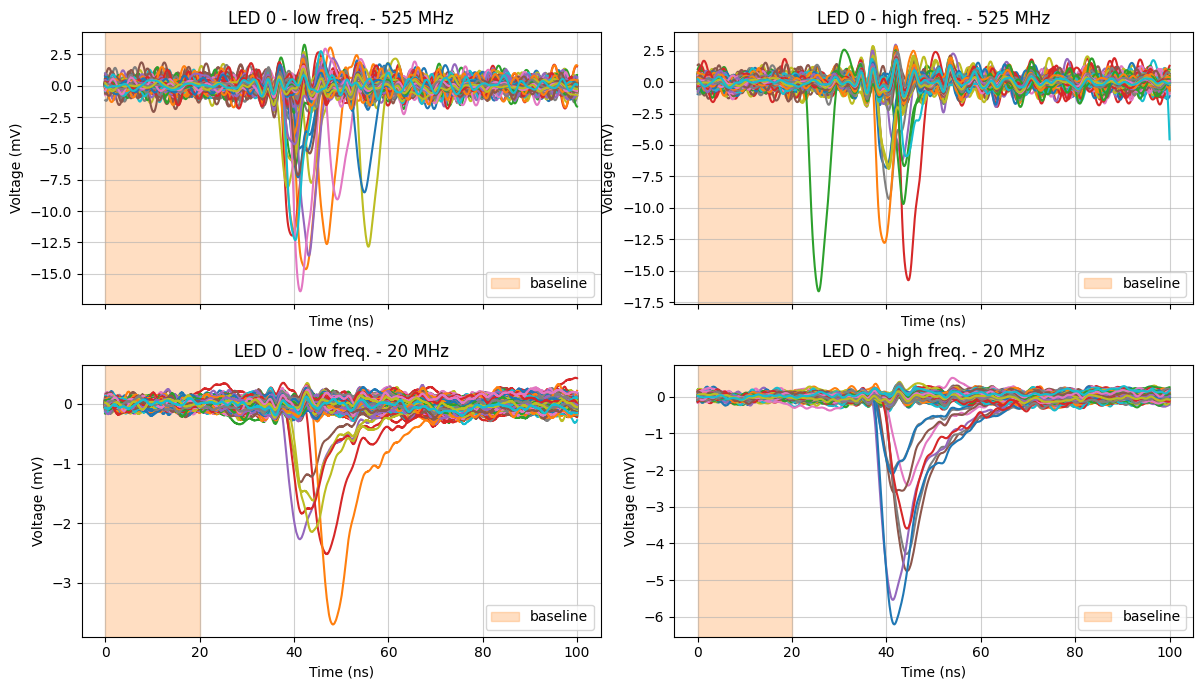

In [11]:
n_to_plot = 1000
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_plot_waveforms(axes[i],data[k][0], data[k][1][:n_to_plot], title=data[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();
save_plot(fig, save_plots, save_dir, "led0", f"waveforms",  Nevents=n_to_plot)



[PosixPath('plots_noise/led0_avg.pdf')]

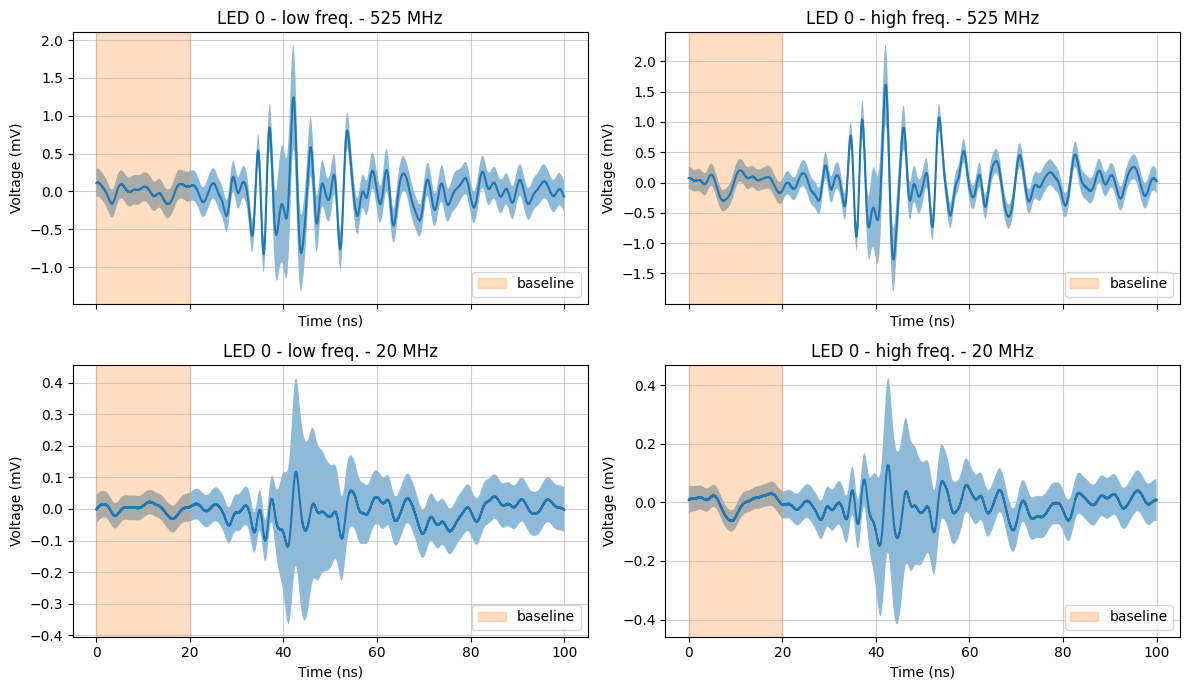

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_mean_waveform(axes[i],data[k][0], data[k][1], title=data[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();

save_plot(fig, save_plots, save_dir, "led0", f"avg",  Nevents=None)

## average in different amplitude bins

In [13]:
data.keys()

dict_keys(['led0_high_525', 'led0_low_525', 'led0_high_20', 'led0_low_20'])

In [36]:
sp = 'led0_high_525'
t, v, df = data[sp][0], data[sp][1], data[sp][2]
# df.head()


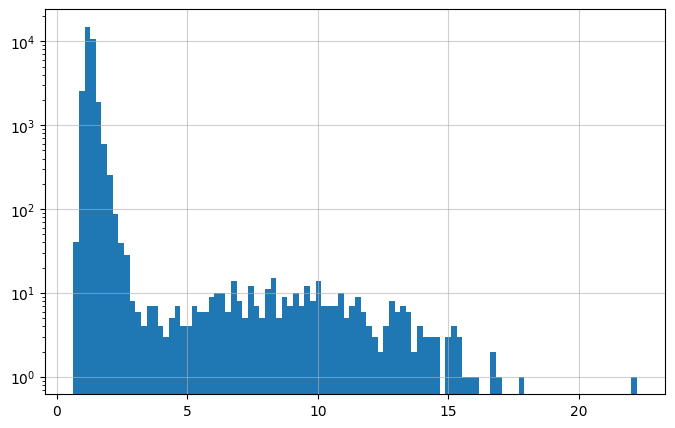

In [37]:
plt.hist(df.peak_amplitude_mV, bins=100, range=None);
plt.yscale('log')

In [38]:
# led0_high_525
bins = [0, 1, 1.25, 1.5, 2, 3, 17]
print(f'min = {np.min(df.peak_amplitude_mV):.2f}, max = {np.max(df.peak_amplitude_mV):.2f}')
counts = ( pd.cut(df["peak_amplitude_mV"], bins=bins).value_counts(sort=False) )
print(counts)

# led0_low_525
# bins = [0, 0.8, 1., 1.5, 2, 2.5, 11]
# print(f'min = {np.min(df.peak_amplitude_mV):.2f}, max = {np.max(df.peak_amplitude_mV):.2f}')
# counts = ( pd.cut(df["peak_amplitude_mV"], bins=bins).value_counts(sort=False) )
# print(counts)

# led0_high_20
# bins = [0, 0.2, 0.4, 0.6, 1, 2, 7]
# print(f'min = {np.min(df.peak_amplitude_mV):.2f}, max = {np.max(df.peak_amplitude_mV):.2f}')
# counts = ( pd.cut(df["peak_amplitude_mV"], bins=bins).value_counts(sort=False) )
# print(counts)

# led0_low_20
# bins = [0, 0.1, 0.2, 0.5, 1, 2, 7]
# print(f'min = {np.min(df.peak_amplitude_mV):.2f}, max = {np.max(df.peak_amplitude_mV):.2f}')
# counts = ( pd.cut(df["peak_amplitude_mV"], bins=bins).value_counts(sort=False) )
# print(counts)

min = 0.63, max = 22.22
peak_amplitude_mV
(0.0, 1.0]       879
(1.0, 1.25]    13992
(1.25, 1.5]    13278
(1.5, 2.0]      2534
(2.0, 3.0]       323
(3.0, 17.0]      383
Name: count, dtype: int64


[PosixPath('plots_noise/led0_high_525_waveforms_binned.pdf')]

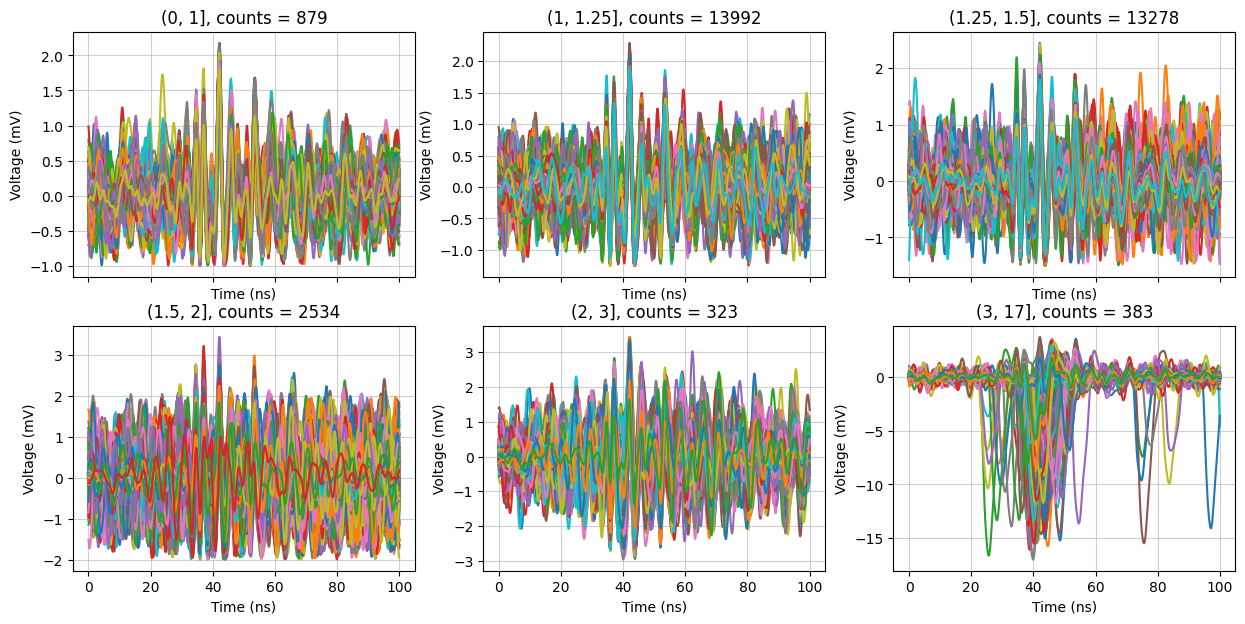

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.ravel()
for i in range(0, len(bins)-1):
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=(bins[i], bins[i+1]) )
    if len(v_sel)> 5000:
        add_plot_waveforms(axes[i], t, v_sel[:2000], title=f"({bins[i]}, {bins[i+1]}], counts = {len(v_sel)}")
    else:
        add_plot_waveforms(axes[i], t, v_sel, title=f"({bins[i]}, {bins[i+1]}], counts = {len(v_sel)}")
save_plot(fig, save_plots, save_dir, sp, f"waveforms_binned",  Nevents=None)

[PosixPath('plots_noise/led0_high_525_avg_binned.pdf')]

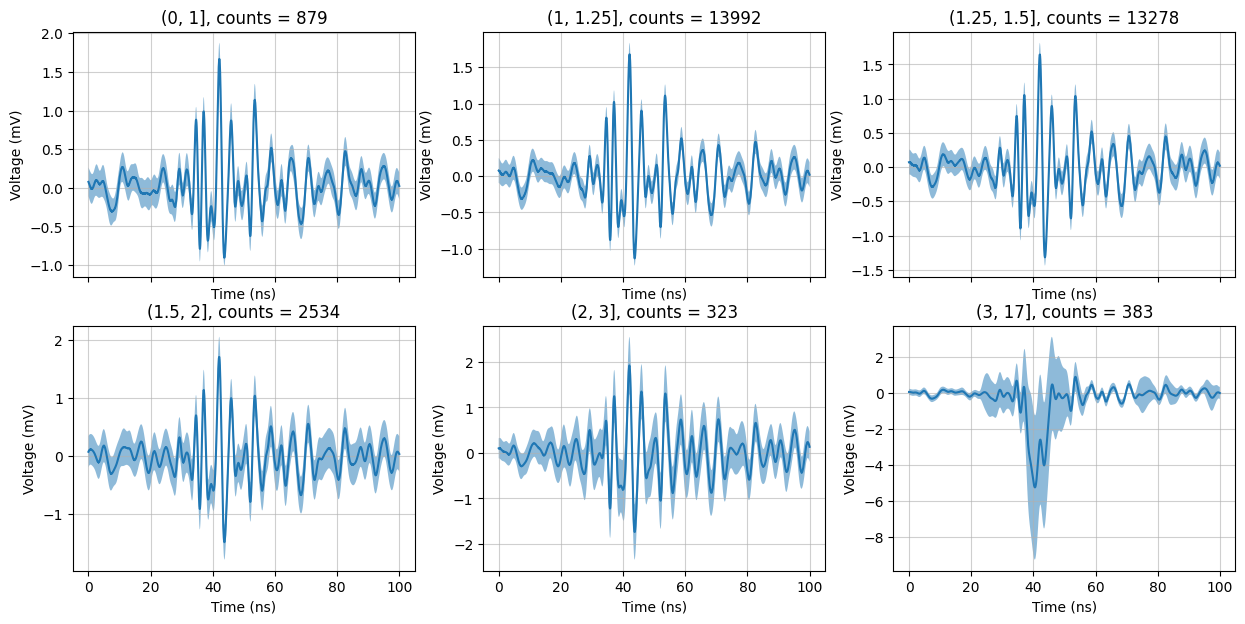

In [40]:

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
axes = axes.ravel()
for i in range(0, len(bins)-1):
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=(bins[i], bins[i+1]) )
    add_mean_waveform(axes[i], t, v_sel, title=f"({bins[i]}, {bins[i+1]}], counts = {len(v_sel)}")
save_plot(fig, save_plots, save_dir, sp, f"avg_binned",  Nevents=None)

## amplitude cut: -2.5mV

[PosixPath('plots_noise/led0_2.8mVampCut_waveforms.pdf')]

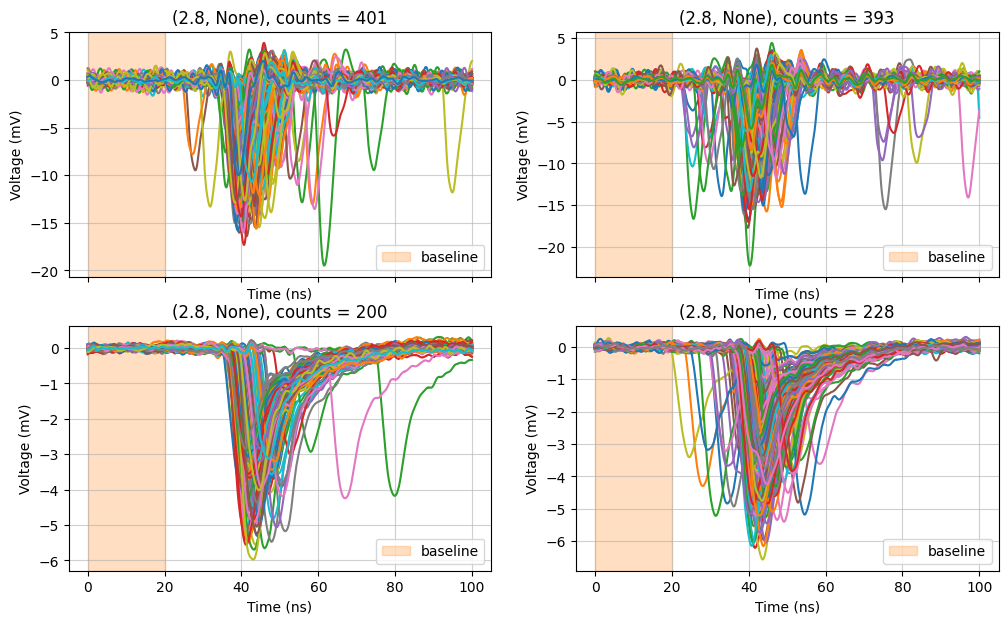

In [49]:
plot_order = ['led0_low_525', 'led0_high_525', 'led0_low_20', 'led0_high_20']

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

cut_rg = (2.8, None)
i = 0
for k in plot_order:
    t, v, df, label = data[k][0], data[k][1], data[k][2], data[k][3]
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=cut_rg )
    add_plot_waveforms(axes[i], t, v_sel, title=f"{cut_rg}, counts = {len(v_sel)}")
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
save_plot(fig, save_plots, save_dir, "led0_2.8mVampCut", f"waveforms",  Nevents=None)

[PosixPath('plots_noise/led0_2.8mVampCut_avg.pdf')]

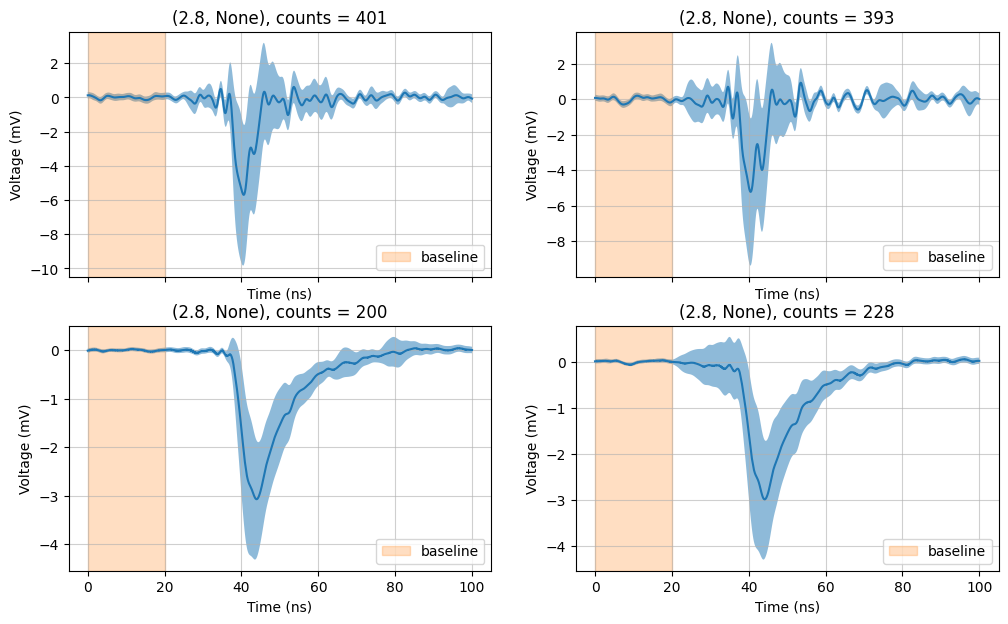

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

cut_rg = (2.8, None)
i = 0
for k in plot_order:
    t, v, df, label = data[k][0], data[k][1], data[k][2], data[k][3]
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=cut_rg )
    add_mean_waveform(axes[i], t, v_sel, title=f"{cut_rg}, counts = {len(v_sel)}")
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
save_plot(fig, save_plots, save_dir, "led0_2.8mVampCut", f"avg",  Nevents=None)

# 1. LED 1

In [44]:


data1 = {}

led = '1'

for BW in ['525', '20']:
    for freq, kf in zip(['HIGH', 'LOW'], ['high', 'low']):
        key = f'led{led}_{kf}_{BW}'
        file_name = f"{data_dir}/led0{led}0_{freq}_850V_{BW}MHz-1.h5"
        print('\n', file_name)
        data1[key] = load_file_one_go([file_name], 512, baseline_window_ns, channel) 
        data1[key].append(f'LED {led} - {kf} freq. - {BW} MHz')

data1.keys()



 data/WA0089/260701/led010_HIGH_850V_525MHz-1.h5
Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31493       99.4%         99.4%

 data/WA0089/260701/led010_LOW_850V_525MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31425       99.2%         99.2%

 data/WA0089/260701/led010_HIGH_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31680      100.0%        100.0%

 data/WA0089/260701/led010_LOW_850V_20MHz-1.h5


/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a prominence of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )
/Users/emiliebertholet/Desktop/Lab/TAU-neutrino-lab_git-repos/PMT-characterization/PMT-calibration/pmt/preprocessing.py:317: PeakPropertyWarning: some peaks have a width of 0
  widths, _, _, _ = peak_widths( v, [pk], rel_height=0.5 )


Cut                            Kept    Relative    Cumulative
--------------------------------------------------------------
Initial                       31682      100.0%        100.0%
peaks in the baseline         31680      100.0%        100.0%


dict_keys(['led1_high_525', 'led1_low_525', 'led1_high_20', 'led1_low_20'])

In [51]:
plot_order = ['led1_low_525', 'led1_high_525', 'led1_low_20', 'led1_high_20']

[PosixPath('plots_noise/led1_waveforms_1000evts.pdf')]

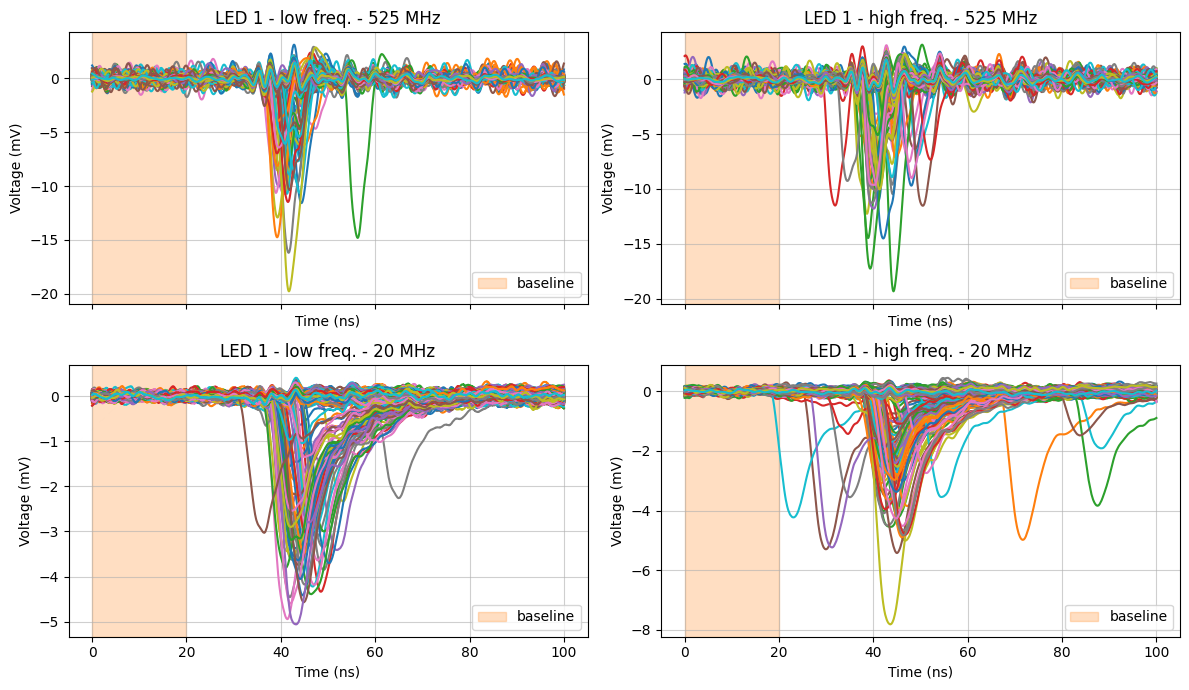

In [52]:
n_to_plot = 1000
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_plot_waveforms(axes[i],data1[k][0], data1[k][1][:n_to_plot], title=data1[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();
save_plot(fig, save_plots, save_dir, "led1", f"waveforms",  Nevents=n_to_plot)


[PosixPath('plots_noise/led1_avg.pdf')]

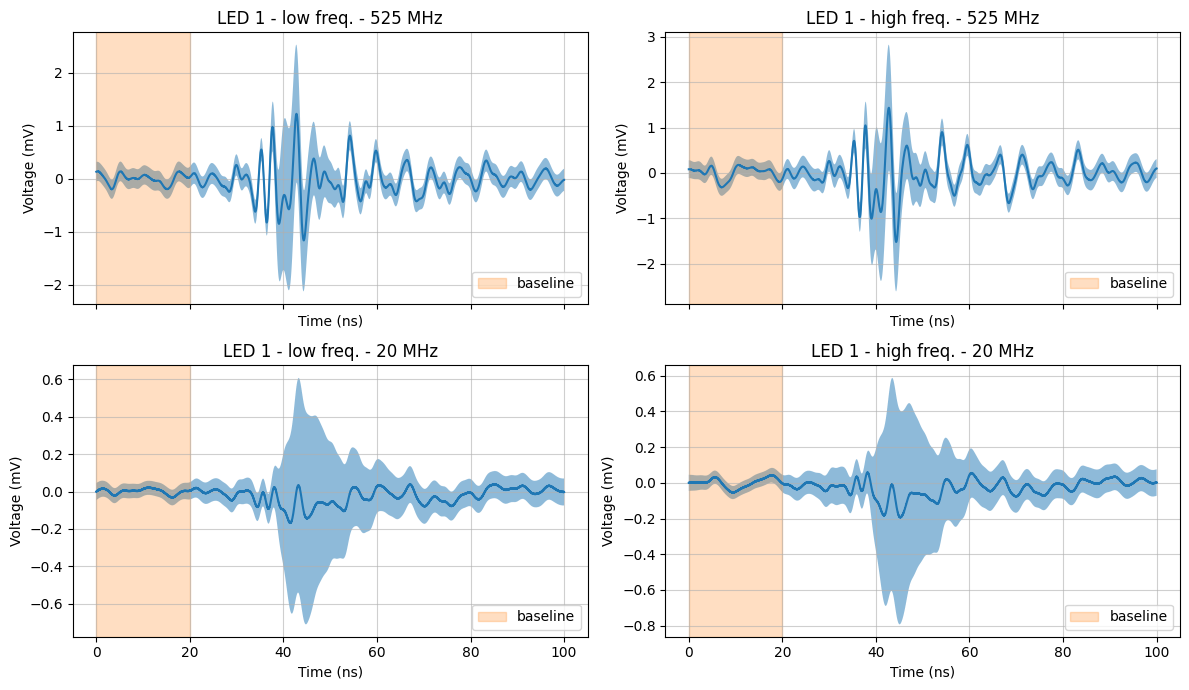

In [53]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
i = 0
for k in plot_order:
    add_mean_waveform(axes[i],data1[k][0], data1[k][1], title=data1[k][3])
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
fig.tight_layout();

save_plot(fig, save_plots, save_dir, "led1", f"avg",  Nevents=None)

[PosixPath('plots_noise/led1_2.8mVampCut_waveforms.pdf')]

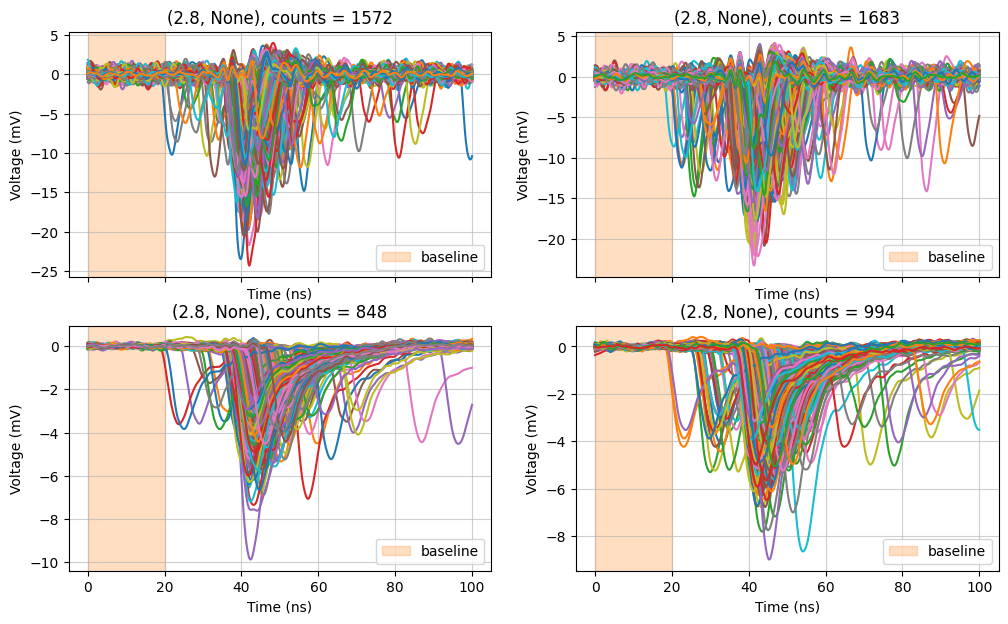

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

cut_rg = (2.8, None)
i = 0
for k in plot_order:
    t, v, df, label = data1[k][0], data1[k][1], data1[k][2], data1[k][3]
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=cut_rg )
    add_plot_waveforms(axes[i], t, v_sel, title=f"{cut_rg}, counts = {len(v_sel)}")
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
save_plot(fig, save_plots, save_dir, "led1_2.8mVampCut", f"waveforms",  Nevents=None)

[PosixPath('plots_noise/led1_2.8mVampCut_avg.pdf')]

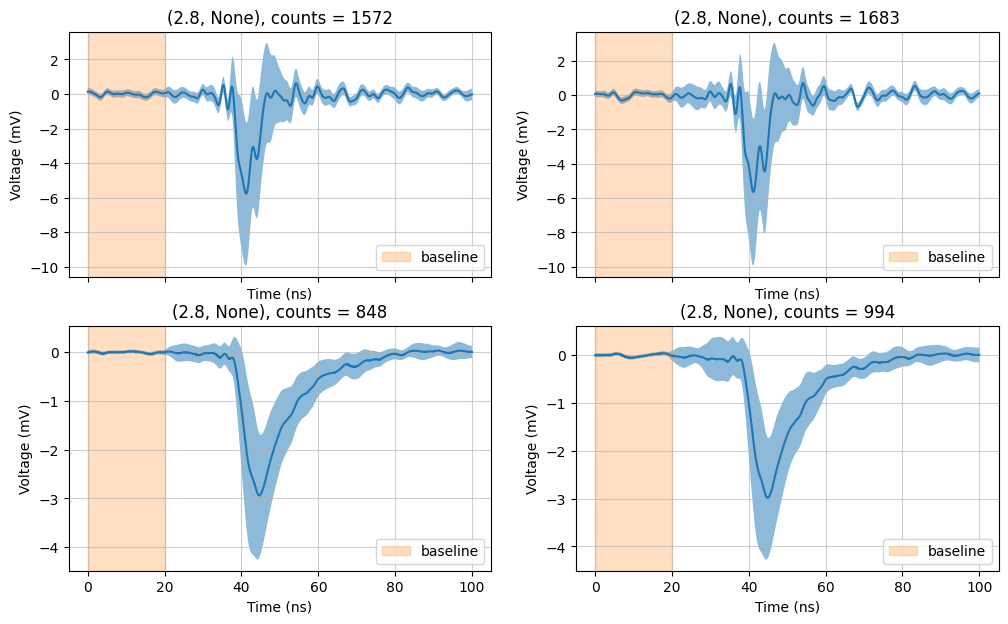

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()

cut_rg = (2.8, None)
i = 0
for k in plot_order:
    t, v, df, label = data1[k][0], data1[k][1], data1[k][2], data1[k][3]
    v_sel, _ = apply_cut_v(df, v, 'peak_amplitude_mV', range=cut_rg )
    add_mean_waveform(axes[i], t, v_sel, title=f"{cut_rg}, counts = {len(v_sel)}")
    axes[i].axvspan(*baseline_window_ns, color="tab:orange", alpha=0.25, label="baseline")
    axes[i].legend(loc="lower right")
    i+=1
save_plot(fig, save_plots, save_dir, "led1_2.8mVampCut", f"avg",  Nevents=None)